In [1]:
import pandas as pd

In [2]:
import os
train_path = r"D:\Pneumonia_Detection\chest_xray\train"
classes = os.listdir(train_path)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['NORMAL', 'PNEUMONIA']
Number of classes: 2


In [4]:
for cls in classes:
    
    class_path = os.path.join(train_path, cls)
    
    count = len(os.listdir(class_path))
    
    print(f"{cls}: {count} images")

NORMAL: 1341 images
PNEUMONIA: 3875 images


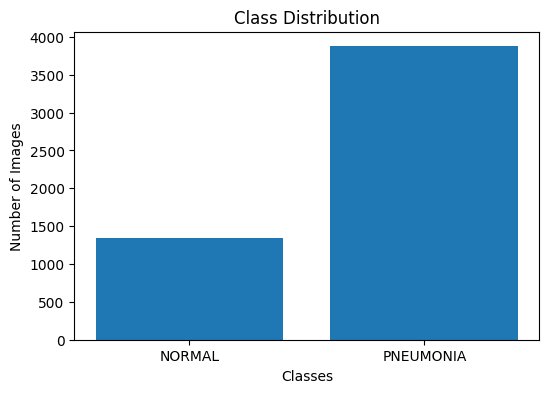

In [5]:
import matplotlib.pyplot as plt

class_counts = []

for cls in classes:
    
    class_path = os.path.join(train_path, cls)
    
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(6,4))

plt.bar(classes, class_counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

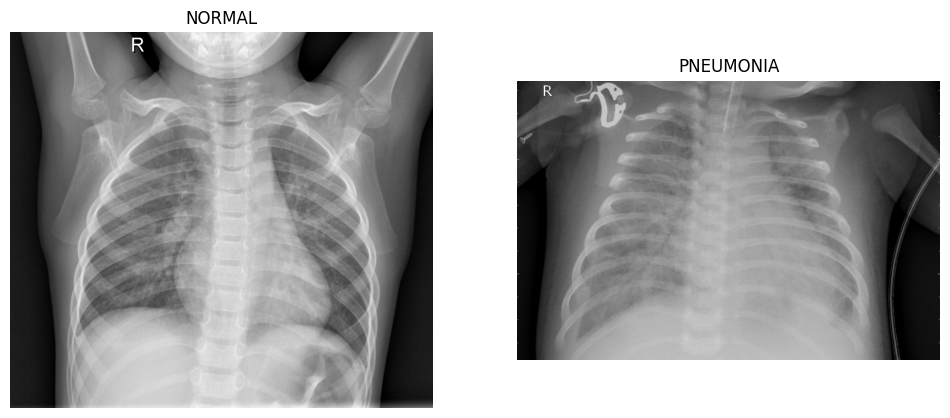

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    
    class_path = os.path.join(train_path, cls)
    
    img_name = os.listdir(class_path)[0]
    
    img_path = os.path.join(class_path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(1,2,i+1)
    
    plt.imshow(img, cmap='gray')
    
    plt.title(cls)
    
    plt.axis("off")

plt.show()

In [4]:
print(img.size)
print(img.mode)

(1152, 760)
L


In [6]:
print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (1152, 760)
Image Mode: L


In [7]:
from PIL import Image
import os

sizes = []

for cls in classes:
    
    class_path = os.path.join(train_path, cls)
    
    images = os.listdir(class_path)
    
    for img_name in images[:50]:
        
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path)
        
        sizes.append(img.size)

print(sizes[:10])

[(2090, 1858), (1422, 1152), (1810, 1434), (1618, 1279), (1600, 1125), (1974, 1306), (1528, 1013), (1384, 1167), (1450, 1144), (1468, 993)]


In [8]:
from PIL import Image
import os

corrupted = []

for cls in classes:
    
    class_path = os.path.join(train_path, cls)
    
    images = os.listdir(class_path)
    
    for img_name in images:
        
        img_path = os.path.join(class_path, img_name)
        
        try:
            img = Image.open(img_path)
            img.verify()
            
        except:
            corrupted.append(img_path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
train_datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    rotation_range=10,
    
    zoom_range=0.1,
    
    width_shift_range=0.1,
    
    height_shift_range=0.1,
    
    horizontal_flip=True
)

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [12]:
val_path = r"D:\Pneumonia_Detection\chest_xray\val"
test_path = r"D:\Pneumonia_Detection\chest_xray\test"

In [13]:
train_data = train_datagen.flow_from_directory(
    
    train_path,
    
    target_size=(224,224),
    
    batch_size=32,
    
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [15]:
images, labels = next(train_data)

print(images.shape)

(32, 224, 224, 3)


In [16]:
print(images[0].shape)

(224, 224, 3)


In [17]:
print(images[0].min())
print(images[0].max())

0.0
0.98287815


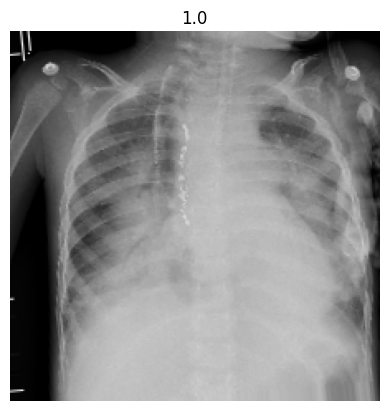

In [18]:
import matplotlib.pyplot as plt

plt.imshow(images[0])

plt.title(labels[0])

plt.axis("off")

plt.show()

In [19]:
val_data = test_datagen.flow_from_directory(
    
    val_path,
    
    target_size=(224,224),
    
    batch_size=32,
    
    class_mode='binary'
)

Found 16 images belonging to 2 classes.


In [20]:
test_data = test_datagen.flow_from_directory(
    
    test_path,
    
    target_size=(224,224),
    
    batch_size=32,
    
    class_mode='binary',
    
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [21]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [22]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    
    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

d:\Pneumonia_Detection\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    
    optimizer='adam',
    
    loss='binary_crossentropy',
    
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    
    monitor='val_loss',
    
    patience=3,
    
    restore_best_weights=True
)

In [25]:
history = model.fit(
    
    train_data,
    
    validation_data=val_data,
    
    epochs=10,
    
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 867ms/step - accuracy: 0.8135 - loss: 0.4131 - val_accuracy: 0.6875 - val_loss: 0.7379
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.8967 - loss: 0.2509 - val_accuracy: 0.7500 - val_loss: 0.6652
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 819ms/step - accuracy: 0.9076 - loss: 0.2320 - val_accuracy: 0.7500 - val_loss: 0.7217
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 824ms/step - accuracy: 0.9160 - loss: 0.2148 - val_accuracy: 0.7500 - val_loss: 0.6521
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 806ms/step - accuracy: 0.9256 - loss: 0.1911 - val_accuracy: 0.8125 - val_loss: 0.5963
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 806ms/step - accuracy: 0.9367 - loss: 0.1664 - val_accuracy: 0.6250 - val_loss: 1.0759
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.9346 - loss: 0.1680 - val_accuracy: 0.6875 - val_loss: 0.6155
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 809ms/step - accuracy: 0.9360 -

In [26]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 613ms/step - accuracy: 0.7756 - loss: 0.5564
Test Loss: 0.5564367175102234
Test Accuracy: 0.7756410241127014


In [27]:
predictions = model.predict(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 337ms/step


In [28]:
predictions = (predictions > 0.5).astype(int)

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_data.classes,
    predictions
)

print(cm)

[[102 132]
 [  8 382]]


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_data.classes,
        predictions,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.93      0.44      0.59       234
   PNEUMONIA       0.74      0.98      0.85       390

    accuracy                           0.78       624
   macro avg       0.84      0.71      0.72       624
weighted avg       0.81      0.78      0.75       624



In [32]:
from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

In [33]:
base_model = DenseNet121(
    
    weights='imagenet',
    
    include_top=False,
    
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [34]:
base_model.trainable = False

In [35]:
x = GlobalAveragePooling2D()(base_model.output)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

In [36]:
model = Model(
    inputs=base_model.input,
    outputs=output
)

In [37]:
model.compile(
    
    optimizer='adam',
    
    loss='binary_crossentropy',
    
    metrics=['accuracy']
)

In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    
    class_weight='balanced',
    
    classes=np.unique(train_data.classes),
    
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [39]:
history = model.fit(
    
    train_data,
    
    validation_data=val_data,
    
    epochs=10,
    
    class_weight=class_weights,
    
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.8528 - loss: 0.3394 - val_accuracy: 0.8750 - val_loss: 0.2546
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9120 - loss: 0.2171 - val_accuracy: 0.8750 - val_loss: 0.2181
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9264 - loss: 0.1770 - val_accuracy: 0.9375 - val_loss: 0.1756
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 429s 3s/step - accuracy: 0.9304 - loss: 0.1664 - val_accuracy: 0.9375 - val_loss: 0.2077
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9367 - loss: 0.1583 - val_accuracy: 0.9375 - val_loss: 0.1930
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9383 - loss: 0.1612 - val_accuracy: 0.8750 - val_loss: 0.2286


In [40]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8926 - loss: 0.2724
Test Loss: 0.27236679196357727
Test Accuracy: 0.8926281929016113


In [41]:
predictions = model.predict(test_data)

predictions = (predictions > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_data.classes,
    predictions
)

print(cm)

[[207  27]
 [ 40 350]]


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_data.classes,
        predictions,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.84      0.88      0.86       234
   PNEUMONIA       0.93      0.90      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.89      0.89       624
weighted avg       0.89      0.89      0.89       624



In [44]:
model.save("pneumonia_densenet_model.h5")

In [45]:
model.save("pneumonia_densenet_model.keras")